In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("winequality.csv", sep= ';')

print(data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [28]:
# Extract two numeric columns: alcohol and density
dataset = []

for row in data.itertuples(index=False):
    dataset.append([float(row.alcohol), float(row.density)])

data_array = np.array(dataset)

print("Dataset shape:", data_array.shape)
print("First 5 rows:", data_array[:5])

Dataset shape: (1599, 2)
First 5 rows: [[9.4    0.9978]
 [9.8    0.9968]
 [9.8    0.997 ]
 [9.8    0.998 ]
 [9.4    0.9978]]


In [15]:
# Mean vector μ
mu = np.mean(data_array, axis=0)

# Covariance matrix Σ
sigma = np.cov(data_array.T)  # transpose to get 2x2 cov

# Correlation coefficient ρ
rho = sigma[0,1] / (np.sqrt(sigma[0,0]) * np.sqrt(sigma[1,1]))

print("Mean vector μ:", mu)
print("Covariance matrix Σ:\n", sigma)
print("Correlation ρ:", rho)

Mean vector μ: [10.42298311  0.99674668]
Covariance matrix Σ:
 [[ 1.13564740e+00 -9.97951790e-04]
 [-9.97951790e-04  3.56202945e-06]]
Correlation ρ: -0.4961797702417017


In [17]:
def bvn_pdf(x, y, mu, sigma, rho):
    sigma_x = np.sqrt(sigma[0,0])
    sigma_y = np.sqrt(sigma[1,1])
    z = ((x - mu[0])**2 / sigma_x**2 +
         (y - mu[1])**2 / sigma_y**2 -
         2*rho*(x - mu[0])*(y - mu[1])/(sigma_x*sigma_y))
    denom = 2 * np.pi * sigma_x * sigma_y * np.sqrt(1 - rho**2)
    return np.exp(-z / (2*(1 - rho**2))) / denom

In [18]:
# Create a grid
x = np.linspace(min(data_array[:,0])-0.5, max(data_array[:,0])+0.5, 100)
y = np.linspace(min(data_array[:,1])-0.001, max(data_array[:,1])+0.001, 100)
X, Y = np.meshgrid(x, y)

# Compute PDF values for each point on the grid
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = bvn_pdf(X[i,j], Y[i,j], mu, sigma, rho)

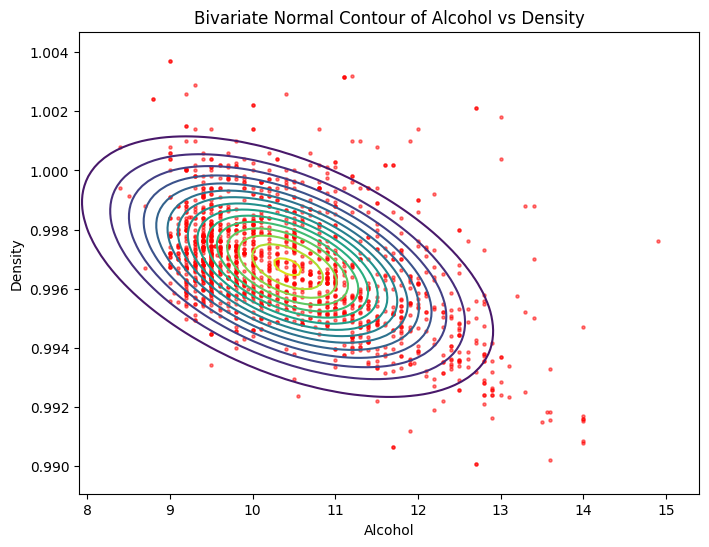

In [24]:
plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=15, cmap='viridis')
plt.scatter(data_array[:,0], data_array[:,1], s=5, color='red', alpha=0.5)
plt.xlabel('Alcohol')
plt.ylabel('Density')
plt.title('Bivariate Normal Contour of Alcohol vs Density')
plt.show()

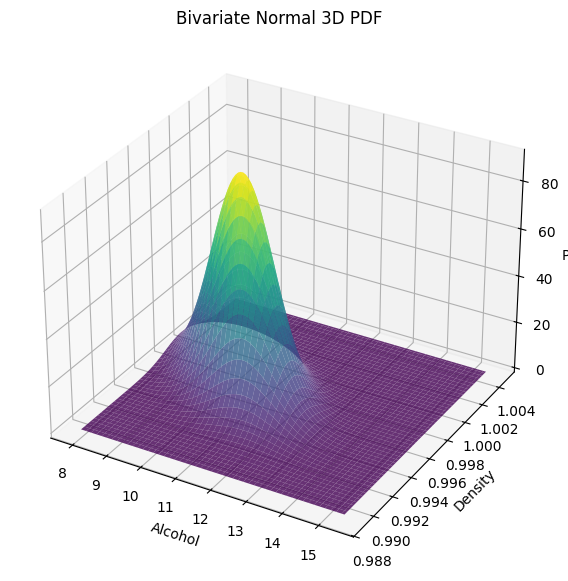

In [27]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('Alcohol')
ax.set_ylabel('Density')
ax.set_zlabel('PDF')
ax.set_title('Bivariate Normal 3D PDF')
plt.show()